In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import torch
import pandas as pd
import pyarrow.parquet as pq
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch
import timm
from torch.optim import AdamW
from torch.nn import CrossEntropyLoss
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import pyarrow.parquet as pq
import pandas as pd
from torch.utils.checkpoint import checkpoint
import torch.nn.init as init
from torch.optim.lr_scheduler import StepLR
import dask.dataframe as dd
import numpy as np
import torch.nn as nn
import torch.optim as optim

In [3]:
#train 데이터셋 로드
# Set the size of each chunk in rows
chunk_size = 50

# Create a Parquet file reader object
parquet_file_train = pq.ParquetFile('/content/drive/MyDrive/machine learning/data/quak vs gluon/QCDToGGQQ_IMGjet_RH1all_jet0_run1_n47540.test.snappy.parquet')
# Determine the total number of rows in the file
total_rows = parquet_file_train.metadata.num_rows

# Loop over the file in chunks
dfs = []
for i in range(0, total_rows, chunk_size):
    # Read a chunk of rows from the file
    chunk = parquet_file_train.read_row_group(i)
    df = chunk.to_pandas()
#     print(i)
    dfs.append(df)        #Chunk size씩 불러와서 dfs에 순차적으로 저장

# Concatenate all the DataFrames into a single DataFrame
final_df_train = pd.concat(dfs, ignore_index=True)    #ingnore_index chunk size씩 묶여 있도록 하지 않고 index를 무시해서 합치게 함

parquet_file_train.read_row_group(0).to_pandas()

#(3,) 배열을 (3,125,125) 배열로 변환하기 위한 함수 정의
'''
def to_3d(arr):
    vishak=[]
    for i in range (0,3):
        vis=np.stack(np.stack(arr)[i],axis=-1)
        vishak.append(vis)
    vishak=np.array(vishak)
    return vishak
'''

# (3,) 배열을 (3, 125, 125) 배열로 변환하는 함수(수정) :numpy.object이기 때문에 나중에 float32로 변환이 안됐음. numpy.ndarray로 바꿔주는 처리
def to_3d(arr):
    arr = np.array(arr)  # 리스트를 numpy 배열로 변환
    if arr.shape == (3,):  # 현재 형태가 (3,)라면 변환 수행
        vishak = [np.stack(np.stack(channel), axis=-1) for channel in arr]
        return np.array(vishak, dtype=np.float32)  # 최종적으로 float32로 변환
    return arr  # 이미 올바른 형태면 그대로 반환

# 'X_jets' 컬럼을 변환
final_df_train['X_jets'] = final_df_train['X_jets'].apply(to_3d)

'''
for i in range (0,726):
    final_df_train['X_jets'][i]=to_3d(final_df_train['X_jets'][i])
    # 'X_jets'를 numpy.float32 타입으로 변환
    final_df_train['X_jets'] = final_df_train['X_jets'].apply(lambda x: np.array(x, dtype=np.float32))
'''
final_df_train['X_jets'][0],final_df_train['X_jets'][0].shape #final_df['X_jets']은 변환된 3,125,125 배열

KeyboardInterrupt: 

In [11]:
#훈련 데이터 더 넣어주기
import pyarrow.parquet as pq
import pandas as pd
import numpy as np

# Set the size of each chunk in rows
chunk_size = 50

# 첫 번째 Parquet 파일 읽기
parquet_file_train_1 = pq.ParquetFile('/content/drive/MyDrive/machine learning/data/quak vs gluon/QCDToGGQQ_IMGjet_RH1all_jet0_run1_n47540.test.snappy.parquet')
total_rows_1 = parquet_file_train_1.metadata.num_rows

# 두 번째 Parquet 파일 읽기
parquet_file_train_2 = pq.ParquetFile('/content/drive/MyDrive/machine learning/data/quak vs gluon/QCDToGGQQ_IMGjet_RH1all_jet0_run2_n55494.test.snappy.parquet')  # 두 번째 파일 경로
total_rows_2 = parquet_file_train_2.metadata.num_rows

# 두 개의 데이터프레임 저장 리스트
dfs_1 = []
dfs_2 = []

# 첫 번째 파일 데이터를 읽어서 dfs_1에 저장
for i in range(0, total_rows_1, chunk_size):
    chunk = parquet_file_train_1.read_row_group(i)
    df = chunk.to_pandas()
    dfs_1.append(df)

# 두 번째 파일 데이터를 읽어서 dfs_2에 저장
for i in range(0, total_rows_2, chunk_size):
    chunk = parquet_file_train_2.read_row_group(i)
    df = chunk.to_pandas()
    dfs_2.append(df)

# 두 데이터프레임 병합
final_df_train_1 = pd.concat(dfs_1, ignore_index=True)
final_df_train_2 = pd.concat(dfs_2, ignore_index=True)

# 두 데이터프레임을 하나로 합침
final_df_train = pd.concat([final_df_train_1, final_df_train_2], ignore_index=True)

# 'X_jets' 컬럼을 변환
def to_3d(arr):
    arr = np.array(arr)  # 리스트를 numpy 배열로 변환
    if arr.shape == (3,):  # 현재 형태가 (3,)라면 변환 수행
        vishak = [np.stack(np.stack(channel), axis=-1) for channel in arr]
        return np.array(vishak, dtype=np.float32)  # 최종적으로 float32로 변환
    return arr  # 이미 올바른 형태면 그대로 반환

# 'X_jets' 컬럼을 변환
final_df_train['X_jets'] = final_df_train['X_jets'].apply(to_3d)

final_df_train['X_jets'][0], final_df_train['X_jets'][0].shape


(array([[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],
 
        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],
 
        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]]], dtype=float32),
 (3, 125, 125))

In [ ]:
# 'X_jets' 컬럼의 일부 데이터 확인
print(final_df_train['X_jets'].head())
print(final_df_train['X_jets'].dtype)


0    [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...
1    [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...
2    [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...
3    [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...
4    [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...
Name: X_jets, dtype: object
object


X_jets 데이터가 object 타입으로 저장되었기 때문에 np.ndarray로 변환한 후 float32로 변환해야함.

final_df_train['X_jets'][i] = to_3d(final_df_train['X_jets'][i]) 코드에서 데이터프레임의 개별 셀을 직접 수정하려고 해서 문제가 발생. -> .apply()를 사용해서 한번에 변환시켜 줌.

In [12]:
#test 데이터셋 로드
# Set the size of each chunk in rows
chunk_size = 50

# Create a Parquet file reader object
parquet_file_test = pq.ParquetFile('/content/drive/MyDrive/machine learning/data/quak vs gluon/QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272.test.snappy.parquet')
# Determine the total number of rows in the file
total_rows = parquet_file_test.metadata.num_rows

# Loop over the file in chunks
dfs_test = []
for i in range(0, total_rows, chunk_size):
    # Read a chunk of rows from the file
    chunk = parquet_file_test.read_row_group(i)
    df_test = chunk.to_pandas()
#     print(i)
    dfs_test.append(df_test)

# Concatenate all the DataFrames into a single DataFrame
final_df_test = pd.concat(dfs_test, ignore_index=True)

parquet_file_test.read_row_group(0).to_pandas()

#(3,) 배열을 (3,125,125) 배열로 변환하기 위한 함수 정의
def to_3d(arr):
    vishak=[]
    for i in range (0,3):
        vis=np.stack(np.stack(arr)[i],axis=-1)
        vishak.append(vis)
    vishak=np.array(vishak)
    return vishak

for i in range (0,726):
    final_df_test['X_jets'][i]=to_3d(final_df_test['X_jets'][i])

final_df_test['X_jets'][0],final_df_test['X_jets'][0].shape #final_df['X_jets']은 변환된 3,125,125 배열

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  final_df_test['X_jets'][i]=to_3d(final_df_test['X_jets'][i])
<ipython-input-12-7e9bcb9778fc>:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df_test['X_jets'][i]=to_3d(final_df_test['X_jets'][i])
<ipython-input-12-7e9bcb9778fc>:34: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a

(array([[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],
 
        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],
 
        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]]]),
 (3, 125, 125))

In [16]:
from torchvision import transforms
class ParquetDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.data = dataframe["X_jets"].values  # 이미지 데이터
        self.labels = dataframe["y"].values  # 라벨 데이터
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx]  # (3, 125, 125) 형태의 이미지
        label = self.labels[idx]  # 정수형 라벨 (0 또는 1)

        if image.shape == (125, 125, 3):  # 🔥 (H, W, C) → (C, H, W) 변환
            image = image.transpose(2, 0, 1)  # (125,125,3) → (3,125,125)


        if isinstance(image, np.ndarray) and image.shape == (3, 125, 125):
            # 🔥 변환 전 데이터가 numpy 배열인지 확인
          image = torch.tensor(image, dtype=torch.float32)  # numpy → torch 변환

        if self.transform:
            image = self.transform(image)

        #손실함수 CrossEntropyLoss를 사용하기 위해서 라벨을 long 타입으로 변환
        label = torch.tensor(label,dtype=torch.long)

        return image, label


# 데이터 변환 (ViT 모델 입력 크기에 맞게 조정) -> 데이터 증강처리를 하면 정확도가 올라갈까?
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # 먼저 충분히 크게 리사이즈
    #transforms.RandomHorizontalFlip(p=0.5),  # 좌우 반전 (50% 확률)
    #transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # 색상 변화
    #transforms.RandomGrayscale(p=0.1),  # 일부 흑백 변환
    #transforms.ToTensor(),  # 텐서 변환
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),  # 정규화

])




In [17]:
from sklearn.model_selection import train_test_split

# 🚀 4️⃣ DataLoader 생성 (Colab RAM 절약)


# 🚀 학습/테스트 데이터 분할 (20% 테스트 데이터)
validation_df, test_df =train_test_split(final_df_test, test_size=0.5, random_state=42)

train_df=final_df_train
#test_df=final_df_test

BATCH_SIZE = 8


# 🚀 테스트용 Dataset & DataLoader 생성



# 🚀 수정된 코드
train_dataset = ParquetDataset(train_df, transform=transform)  # ✅ train_df만 사용
test_dataset = ParquetDataset(test_df, transform=transform)  # ✅ test_df만 사용
validation_dataset = ParquetDataset(validation_df, transform=transform)


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=True)


print(f"✅ Train Samples: {len(train_df)}, Test Samples: {len(test_df)}")
print(f"Total training samples in dataset: {len(train_dataset)}")  # ✅ 363개여야 함
print(f"Total test samples in dataset: {len(test_dataset)}")  # ✅ 363개여야 함
print(f"Total validation samples in dataset: {len(validation_dataset)}")  # ✅ 363개여야 함

✅ Train Samples: 2061, Test Samples: 363
Total training samples in dataset: 2061
Total test samples in dataset: 363
Total validation samples in dataset: 363


In [18]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. 모델 불러오기 (timm을 사용하여 사전 학습된 ViT 모델 로드)
model_name = 'vit_large_patch16_224'
model = timm.create_model(model_name, pretrained=True, drop_rate=0.2)

# 2. 출력 레이어 수정 (새로운 클래스 개수에 맞게 수정)
num_classes = 2  # 새로운 클래스 수
model.head = torch.nn.Linear(model.head.in_features, num_classes)

# 가중치 초기화
init.xavier_uniform_(model.head.weight)  # Xavier 초기화 (적절한 초기화 방법 선택)
init.zeros_(model.head.bias)
'''
# 1. 모델의 모든 파라미터를 학습 가능하게 설정
for param in model.parameters():
    param.requires_grad = True  # 모델의 모든 레이어를 학습
'''
# 4. 학습 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# 옵티마이저와 손실 함수 설정 + L2 정규화 추가
#optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=5e-4)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9, weight_decay=1e-4)   #요 optimizer가 과적합을 줄이고 일반화 성능이 높다고 해서 써봤는데 미세하게 높음. (RAdam도 써볼 예정)
criterion = CrossEntropyLoss()

# Scheduler 설정 (옵션)
scheduler = StepLR(optimizer, step_size=3, gamma=0.1)

# 5. Fine-tuning 학습 (Gradient Checkpointing 적용)
def checkpointed_forward(model, image):
    # Forward pass with checkpointing to save memory
    image.requires_grad_()   #gradient 추적 활성화
    return checkpoint(model, image)

# 6. Fine-tuning 학습
for epoch in range(10):  # 에폭 수
    model.train()
    total_loss = 0
    for image, label in train_loader:
        image, label = image.to(device), label.to(device)

        # Forward pass with checkpointing
        outputs = checkpointed_forward(model, image)

        loss = criterion(outputs, label)
        total_loss += loss.item()

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    avg_loss = total_loss / len(train_loader)

    # Validation Step
    model.eval()
    val_loss = 0
    val_true_labels = []
    val_preds = []

    with torch.no_grad():
        for image, label in validation_loader:
            image, label = image.to(device), label.to(device)
            outputs = model(image)
            loss = criterion(outputs, label)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            val_true_labels.extend(label.cpu().numpy())
            val_preds.extend(predicted.cpu().numpy())

    avg_val_loss = val_loss / len(validation_loader)
    val_accuracy = accuracy_score(val_true_labels, val_preds)

    print(f"Epoch {epoch+1}: Validation Loss={avg_val_loss:.4f}, Validation Accuracy={val_accuracy:.4f}")
    print(f"Epoch {epoch + 1}, Loss: {avg_loss}")


    #scheduler.step()  # 학습률 조정 (옵션)

# 7. 학습 완료 후 모델 저장
torch.save(model.state_dict(), '/content/drive/MyDrive/machine learning/data/quak vs gluon/ViT_model_large_train.pth')
print("Model saved successfully.")

Epoch 1: Validation Loss=0.8880, Validation Accuracy=0.5620
Epoch 1, Loss: 0.8445562849673189


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch 2: Validation Loss=0.6948, Validation Accuracy=0.6281
Epoch 2, Loss: 0.6139918568637944


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch 3: Validation Loss=0.6458, Validation Accuracy=0.6584
Epoch 3, Loss: 0.5665456019053163


...

Epoch 8: Validation Loss=1.0858, Validation Accuracy=0.6446
Epoch 8, Loss: 0.3099612959393466


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch 9: Validation Loss=1.0412, Validation Accuracy=0.6116
Epoch 9, Loss: 0.26411932761340523


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch 10: Validation Loss=1.3322, Validation Accuracy=0.6281
Epoch 10, Loss: 0.23646029065428084
Model saved successfully.


In [19]:
# 테스트 파트
import torch
import timm
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torch import nn
from sklearn.metrics import accuracy_score
from PIL import Image

# 1. 모델 불러오기 (timm을 사용하여 사전 학습된 ViT 모델 로드)
model_name = 'vit_large_patch16_224'
model = timm.create_model(model_name, pretrained=False)

# 2. 출력 레이어 수정 (새로운 클래스 개수에 맞게 수정)
num_classes = 2  # 새로운 클래스 수
model.head = nn.Linear(model.head.in_features, num_classes)  # 출력 레이어 크기 변경

# 3. 저장된 모델의 가중치 불러오기
model.load_state_dict(torch.load('/content/drive/MyDrive/machine learning/data/quak vs gluon/ViT_model_large_train.pth'))  # 모델 경로 수정

# 4. 모델을 GPU 또는 CPU로 이동
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# 5. 모델 test 하기

def predict_image(image):
    model.eval()  # 모델을 평가 모드로 설정
    with torch.no_grad():
        outputs = model(image)
        _, predicted = torch.max(outputs, 1)
    return predicted.item()

# 6. 테스트 데이터에 대해 정확도 평가

# 정확도 계산
true_label = []
pred_label = []

for image, label in test_loader:
    image, label = image.to(device), label.to(device)
    outputs = model(image)
    _, predicted = torch.max(outputs, 1)

    true_label.extend(label.cpu().numpy())
    pred_label.extend(predicted.cpu().numpy())

test_accuracy = accuracy_score(true_label, pred_label)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")



<ipython-input-19-81198e0b12cb>:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('/content/drive/MyDrive/machine learning/data/quak vs gluo

Test Accuracy: 60.88%


In [20]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# 모델 테스트 함수
def evaluate(model, test_loader, device):
    model.eval()  # 모델을 평가 모드로 변경
    predictions = []
    labels = []
    probabilities = []

    with torch.no_grad():  # 그래디언트 계산 비활성화 (메모리 절약)
        for image, label in test_loader:
            image, label = image.to(device), label.to(device)

            outputs = model(image)
            probs = torch.nn.functional.softmax(outputs, dim=1)[:, 1]  # 클래스 1의 확률
            preds = torch.argmax(outputs, dim=1)  # 가장 높은 확률을 가진 클래스 선택

            predictions.extend(preds.cpu().numpy())
            labels.extend(label.cpu().numpy())
            probabilities.extend(probs.cpu().numpy())

    return predictions, labels, probabilities

# 테스트 실행
preds, true_labels, probs = evaluate(model, test_loader, device)

# 정확도 출력
accuracy = accuracy_score(true_labels, preds)
print(f'Test Accuracy: {accuracy:.4f}')

# AUC 출력
auc = roc_auc_score(true_labels, probs)
print(f'Test AUC: {auc:.4f}')

# 분류 리포트 출력
print("Classification Report:")
print(classification_report(true_labels, preds))

# 혼동 행렬 출력
cm = confusion_matrix(true_labels, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


KeyboardInterrupt: 

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.61      0.63       188
           1       0.61      0.65      0.63       175

    accuracy                           0.63       363
   macro avg       0.63      0.63      0.63       363
weighted avg       0.63      0.63      0.63       363



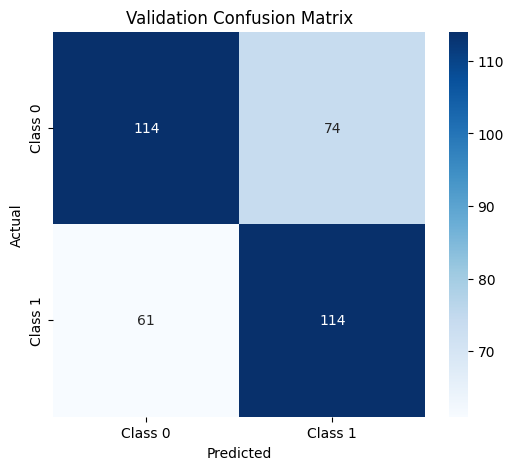

In [21]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Validation 데이터 평가
model.eval()
val_preds = []
val_true_labels = []

with torch.no_grad():
    for image, label in validation_loader:
        image, label = image.to(device), label.to(device)
        outputs = model(image)
        _, predicted = torch.max(outputs, 1)

        val_true_labels.extend(label.cpu().numpy())
        val_preds.extend(predicted.cpu().numpy())

# Confusion Matrix 생성
cm = confusion_matrix(val_true_labels, val_preds)
print("Classification Report:")
print(classification_report(val_true_labels, val_preds))

# 시각화
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Validation Confusion Matrix")
plt.show()


<ipython-input-26-743b57f3cfec>:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('/content/drive/MyDrive/machine learning/data/quak vs gluo

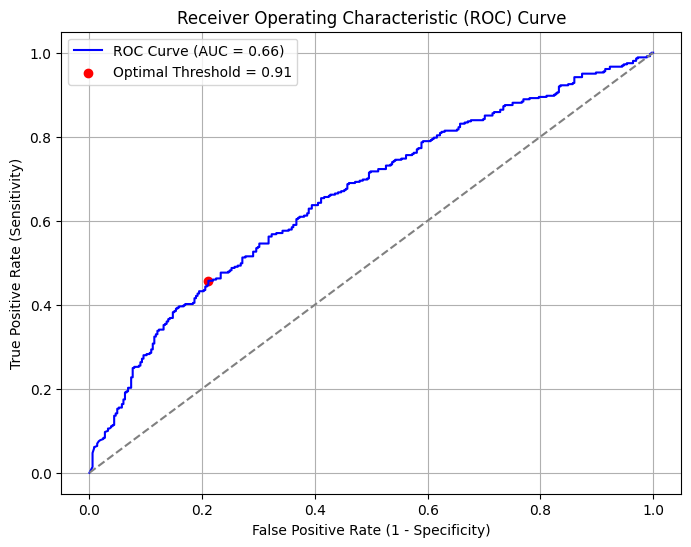

최적 Threshold: 0.9124


In [ ]:
#ROC Curve 분석하여서 최적 임계값 찾기
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1️⃣ 모델 불러오기
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = 'vit_large_patch16_224'
model = timm.create_model(model_name, pretrained=False, num_classes=2)  # num_classes=2 설정
model.load_state_dict(torch.load('/content/drive/MyDrive/machine learning/data/quak vs gluon/ViT_model_large.pth'))
model.to(device)
model.eval()  # 평가 모드

# 2️⃣ 실제 레이블과 예측 확률 저장
y_true = []
y_probs = []

with torch.no_grad():  # Gradient 계산 비활성화
    for image, label in test_loader:
        image, label = image.to(device), label.to(device)
        outputs = torch.softmax(model(image), dim=1)  # 확률 값으로 변환 (Softmax 적용)
        y_true.extend(label.cpu().numpy())  # 실제 정답 저장
        y_probs.extend(outputs[:, 1].cpu().numpy())  # 클래스 1(Positive)의 확률 저장

# 3️⃣ ROC Curve 계산
fpr, tpr, thresholds = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

# 4️⃣ 최적 Threshold 찾기 (Youden's J Statistic)
J = tpr - fpr
optimal_idx = np.argmax(J)
optimal_threshold = thresholds[optimal_idx]

# 5️⃣ ROC Curve 시각화
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # 랜덤 분류 기준선
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], marker='o', color='red', label=f'Optimal Threshold = {optimal_threshold:.2f}')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid()
plt.show()

print(f'최적 Threshold: {optimal_threshold:.4f}')


In [ ]:
# 테스트 데이터에 최적 Threshold 적용
y_pred_optimal = (np.array(y_probs) >= optimal_threshold).astype(int)

# 정확도 및 성능 확인
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred_optimal))

print("\nClassification Report:")
print(classification_report(y_true, y_pred_optimal))


Confusion Matrix:
[[288  77]
 [196 165]]

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.79      0.68       365
           1       0.68      0.46      0.55       361

    accuracy                           0.62       726
   macro avg       0.64      0.62      0.61       726
weighted avg       0.64      0.62      0.61       726



In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score

# 다양한 Threshold 값에 따른 성능 비교
thresholds = np.linspace(0.8, 0.95, 10)  # 0.8 ~ 0.95 사이 10개의 임계값 테스트
best_threshold = 0
best_accuracy = 0

for thresh in thresholds:
    y_pred_thresh = (y_probs >= thresh).astype(int)
    acc = accuracy_score(y_true, y_pred_thresh)
    print(f"Threshold: {thresh:.4f} | Accuracy: {acc:.4f}")

    if acc > best_accuracy:
        best_accuracy = acc
        best_threshold = thresh

print(f"\n🌟 최적 Threshold: {best_threshold:.4f} | 최적 Accuracy: {best_accuracy:.4f}")


Threshold: 0.8000 | Accuracy: 0.6143
Threshold: 0.8167 | Accuracy: 0.6171
Threshold: 0.8333 | Accuracy: 0.6185
Threshold: 0.8500 | Accuracy: 0.6157
Threshold: 0.8667 | Accuracy: 0.6212
Threshold: 0.8833 | Accuracy: 0.6171
Threshold: 0.9000 | Accuracy: 0.6212
Threshold: 0.9167 | Accuracy: 0.6198
Threshold: 0.9333 | Accuracy: 0.6185
Threshold: 0.9500 | Accuracy: 0.6143

🌟 최적 Threshold: 0.8667 | 최적 Accuracy: 0.6212


In [ ]:
import numpy as np
import torch
from sklearn.metrics import classification_report, confusion_matrix

# 1️⃣ 모델의 확률 예측 수행 (이전 코드에서 가져온 y_probs)
y_probs = np.array(y_probs)  # 리스트를 NumPy 배열로 변환

# 2️⃣ 최적 Threshold 적용 (0.9124 이상이면 1, 미만이면 0)
optimal_threshold = 0.8667
y_pred_optimal = (y_probs >= optimal_threshold).astype(int)

# 3️⃣ 모델 성능 평가 (Confusion Matrix & Classification Report)
print("✅ Confusion Matrix (Optimal Threshold 적용):")
print(confusion_matrix(y_true, y_pred_optimal))

print("\n✅ Classification Report (Optimal Threshold 적용):")
print(classification_report(y_true, y_pred_optimal))


✅ Confusion Matrix (Optimal Threshold 적용):
[[279  86]
 [189 172]]

✅ Classification Report (Optimal Threshold 적용):
              precision    recall  f1-score   support

           0       0.60      0.76      0.67       365
           1       0.67      0.48      0.56       361

    accuracy                           0.62       726
   macro avg       0.63      0.62      0.61       726
weighted avg       0.63      0.62      0.61       726

